# 0. Установка и импорт библиотек

In [19]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify hdbscan folium

# 1. Импорт библиотек и загрузка данных

In [11]:
import geopandas as gpd

# Считываем сохраненный файл прямо в сессию Colab
# Если скачала CSV: gdf = gpd.read_file('export.csv')
gdf = gpd.read_file('export.geojson')

# Если в файле колонки назывались по-другому, подгоняем под структуру:
if 'tags' in gdf.columns:
    # Иногда OSM-экспорт зашивает параметры в словари
    gdf['name'] = gdf['name'].fillna('Без названия')

print(f"Загружено объектов: {len(gdf)}")
print(gdf[['name', 'amenity', 'geometry']].head())

Загружено объектов: 7810
              name     amenity                   geometry
0  Русская рыбалка  restaurant  POINT (30.23314 59.96927)
1        Mama Roma  restaurant  POINT (30.30684 59.96282)
2           Слойка   fast_food  POINT (30.31186 59.95924)
3        Мама Рада  restaurant  POINT (30.34758 59.93252)
4         Снежинка  restaurant  POINT (30.30168 59.96316)


# 3. Перевод в метровую проекцию

In [12]:
# Переводим из градусов (4326) в метры (32636 — UTM 36N для СПб)
gdf_metric = gdf.to_crs(epsg=32636)

# Извлекаем координаты X и Y в виде матрицы для алгоритмов кластеризации
coords = np.column_stack((gdf_metric.geometry.x, gdf_metric.geometry.y))
print("Координаты успешно переведены в метры.")

Координаты успешно переведены в метры.


# 4. Метод «локтя» (Elbow Method) для поиска EPS

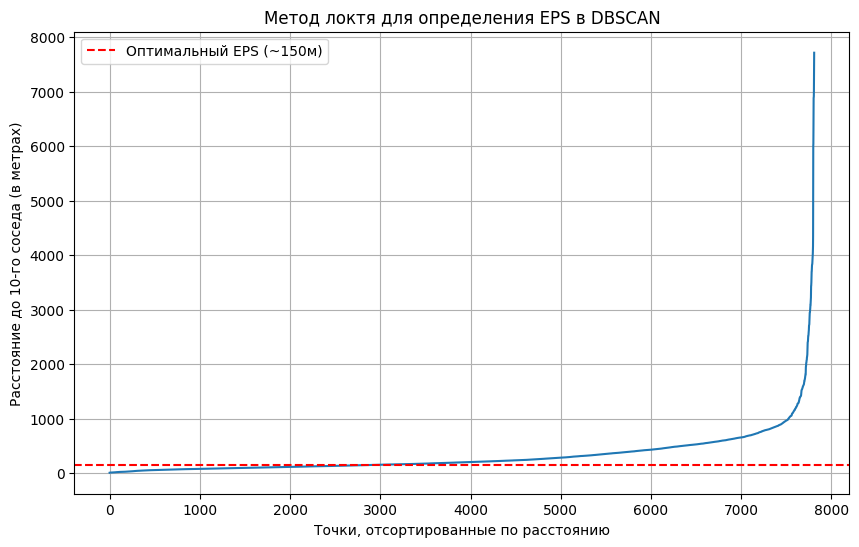

In [13]:
# Ищем расстояния до k-го ближайшего соседа (возьмем min_samples = 10)
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(coords)
distances, indices = neighbors_fit.kneighbors(coords)

# Сортируем расстояния по возрастанию
sort_distances = np.sort(distances[:, min_samples-1], axis=0)

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(sort_distances)
plt.title("Метод локтя для определения EPS в DBSCAN")
plt.xlabel("Точки, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до {min_samples}-го соседа (в метрах)")
plt.grid(True)
plt.axhline(y=150, color='r', linestyle='--', label='Оптимальный EPS (~150м)')
plt.legend()
plt.show()

# 5. Кластеризация DBSCAN

In [14]:
# Задаем параметры на основе графика (например, радиус 150 метров, минимум 10 заведений)
dbscan_model = DBSCAN(eps=150, min_samples=10)
gdf['dbscan_cluster'] = dbscan_model.fit_predict(coords)

db_clusters = len(set(gdf['dbscan_cluster'])) - (1 if -1 in gdf['dbscan_cluster'].values else 0)
db_noise = list(gdf['dbscan_cluster']).count(-1)

print(f"DBSCAN определил кластеров: {db_clusters}")
print(f"Количество шумовых точек (вне кластеров): {db_noise}")

DBSCAN определил кластеров: 106
Количество шумовых точек (вне кластеров): 4048


# 6. Кластеризация HDBSCAN (с переменной плотностью)

In [16]:
import hdbscan

# Настраиваем hdbscan:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=10, prediction_data=True)
gdf['hdbscan_cluster'] = hdbscan_model.fit_predict(coords)
gdf['hdbscan_prob'] = hdbscan_model.probabilities_

hdb_clusters = len(set(gdf['hdbscan_cluster'])) - (1 if -1 in gdf['hdbscan_cluster'].values else 0)
hdb_noise = list(gdf['hdbscan_cluster']).count(-1)

print(f"HDBSCAN определил кластеров: {hdb_clusters}")
print(f"Количество шумовых точек: {hdb_noise}")

HDBSCAN определил кластеров: 118
Количество шумовых точек: 2726


# 7: Сравнительный анализ и агрегация

In [17]:
# Создаем итоговую таблицу для отчета
summary_data = {
    "Метрика": ["Количество кластеров", "Количество шумовых точек"],
    "DBSCAN": [db_clusters, db_noise],
    "HDBSCAN": [hdb_clusters, hdb_noise]
}
summary_df = pd.DataFrame(summary_data)
print("--- Сравнение результатов алгоритмов ---")
print(summary_df)

# Пример группировки: топ-5 самых крупных кластеров в HDBSCAN
print("\n--- Топ-5 крупнейших кластеров по версии HDBSCAN ---")
print(gdf[gdf['hdbscan_cluster'] != -1]['hdbscan_cluster'].value_counts().head(5))

--- Сравнение результатов алгоритмов ---
                    Метрика  DBSCAN  HDBSCAN
0      Количество кластеров     106      118
1  Количество шумовых точек    4048     2726

--- Топ-5 крупнейших кластеров по версии HDBSCAN ---
hdbscan_cluster
80     534
102    200
107    143
3      125
47     101
Name: count, dtype: int64


# 8. Интерактивная визуализация на карте (Folium)

In [21]:
import folium

# Строим интерактивную карту для центра Санкт-Петербурга
m = folium.Map(location=[59.9342, 30.3351], zoom_start=11, tiles="CartoDB positron")

# Ограничим отображение (например, первые 1000 точек), чтобы карта не зависала
gdf_sample = gdf.head(1000)

# Генерируем случайные цвета для кластеров
unique_clusters = gdf_sample['hdbscan_cluster'].unique()
colors = {cluster: f"#{np.random.randint(0, 0xFFFFFF):06x}" for cluster in unique_clusters}
colors[-1] = "#A9A9A9" # Серый цвет для шума

for idx, row in gdf_sample.iterrows():
    cluster_id = row['hdbscan_cluster']
    popup_text = f"Объект: {row['name']}<br>Кластер: {cluster_id}<br>Вероятность: {row['hdbscan_prob']:.2f}"

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4 if cluster_id != -1 else 2,
        color=colors[cluster_id],
        fill=True,
        fill_color=colors[cluster_id],
        fill_opacity=0.7 if cluster_id != -1 else 0.3,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(m)

# Отобразить карту в Colab
m